In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [40]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [41]:
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [42]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [43]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [44]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [45]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [46]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [47]:
print(df.head())
print(df.columns)
print(df.dtypes)

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [48]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 8)
y shape: (891,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 8)
X_test: (179, 8)
y_train: (712,)
y_test: (179,)


In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[98 12]
 [23 46]]


In [52]:
print(confusion_matrix(y_test, y_pred))

[[98 12]
 [23 46]]


In [53]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

[[96 14]
 [18 51]]


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[97 13]
 [22 47]]


In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.72625698 0.78089888 0.81460674 0.74157303 0.84269663]
Mean CV Accuracy: 0.78120645282782


In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy: 0.8217078695951937


In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

final_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Accuracy: 0.7653631284916201

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179


Confusion Matrix:
[[97 13]
 [29 40]]


In [58]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
1         Sex    0.316638
2         Age    0.252508
5        Fare    0.233430
0      Pclass    0.110281
7  Embarked_S    0.032651
4       Parch    0.029445
3       SibSp    0.019436
6  Embarked_Q    0.005611


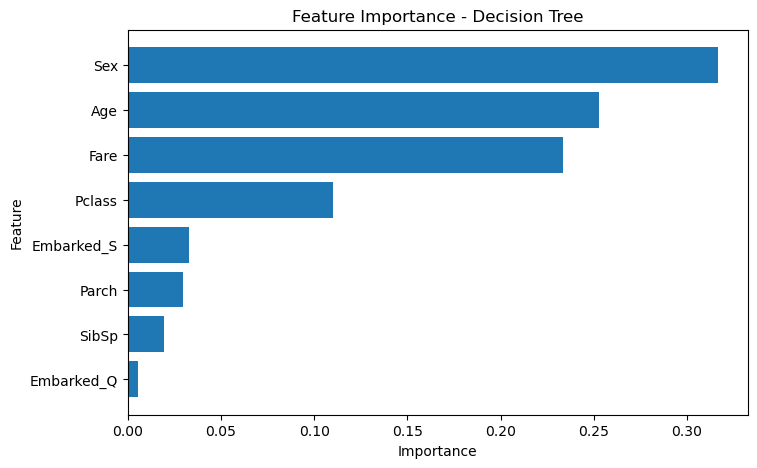

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Decision Tree")

plt.gca().invert_yaxis()
plt.show()

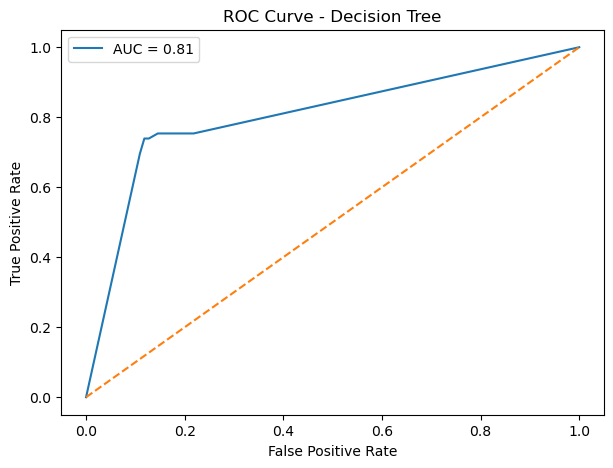

AUC Score: 0.8050724637681159


In [60]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = dt_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

In [61]:
import joblib

joblib.dump(dt_model, "titanic_decision_tree.pkl")

print("Model saved successfully!")

Model saved successfully!


In [63]:
new_passenger = [[1, 22, 7.25, 1, 0, 0, 1, 0]]

prediction = dt_model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger is predicted to SURVIVE")
else:
    print("Passenger is predicted NOT TO SURVIVE")

Passenger is predicted to SURVIVE


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [64]:
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


In [65]:
new_passenger = [[1, 0, 22, 1, 0, 71.28, 0, 0]]

prediction = dt_model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger is predicted to SURVIVE")
else:
    print("Passenger is predicted NOT TO SURVIVE")

Passenger is predicted to SURVIVE


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [66]:
new_passenger = pd.DataFrame([{
    'Pclass': 1,
    'Sex': 0,
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 71.28,
    'Embarked_Q': 0,
    'Embarked_S': 0
}])

prediction = dt_model.predict(new_passenger)

print("Prediction:", prediction[0])

Prediction: 1
